In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

# Load data and hub scores
df = pd.read_csv('../data/delivery_data.csv')
df = df[df['segment_factor'] > 0].dropna(subset=['source_name', 'destination_name'])
hub_scores = pd.read_csv('../data/hub_bottleneck_scores.csv')
hub_scores_indexed = hub_scores.set_index('hub')
hub_score_dict = dict(zip(hub_scores['hub'], hub_scores['bottleneck_score']))

# Add graph features
df['source_bottleneck'] = df['source_center'].map(hub_score_dict).fillna(0)
df['dest_bottleneck'] = df['destination_center'].map(hub_score_dict).fillna(0)
df['source_in_degree'] = df['source_center'].map(hub_scores_indexed['in_degree']).fillna(0)
df['source_avg_delay'] = df['source_center'].map(hub_scores_indexed['avg_delay']).fillna(df['segment_factor'].median())
df['corridor_risk'] = df['source_bottleneck'] + df['dest_bottleneck']

# Compare FTL vs Carting performance
print("=== FTL vs Carting: Key Metrics ===")
comparison = df.groupby('route_type').agg(
    trip_count=('trip_uuid', 'count'),
    avg_actual_time=('actual_time', 'mean'),
    avg_distance=('actual_distance_to_destination', 'mean'),
    avg_delay_factor=('segment_factor', 'mean'),
    avg_osrm_time=('osrm_time', 'mean')
).round(2)
print(comparison)

=== FTL vs Carting: Key Metrics ===
            trip_count  avg_actual_time  avg_distance  avg_delay_factor  \
route_type                                                                
Carting          43515            70.30         26.62              2.74   
FTL              98210           578.65        330.97              2.07   

            avg_osrm_time  
route_type                 
Carting             30.45  
FTL                299.56  


In [3]:
# Encode target
le = LabelEncoder()
df['route_encoded'] = le.fit_transform(df['route_type'])  # Carting=0, FTL=1

# Features including graph position
features = [
    'osrm_time',
    'osrm_distance',
    'actual_distance_to_destination',
    'segment_osrm_time',
    'segment_osrm_distance',
    'source_bottleneck',
    'dest_bottleneck',
    'source_in_degree',
    'source_avg_delay',
    'corridor_risk'
]

X = df[features].reset_index(drop=True)
y = df['route_encoded'].reset_index(drop=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train classifier
print("Training FTL vs Carting classifier...")
clf = xgb.XGBClassifier(n_estimators=100, random_state=42, verbosity=0)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred, target_names=['Carting', 'FTL']))

Training FTL vs Carting classifier...

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

     Carting       1.00      0.99      0.99      8715
         FTL       1.00      1.00      1.00     19630

    accuracy                           1.00     28345
   macro avg       1.00      0.99      1.00     28345
weighted avg       1.00      1.00      1.00     28345



In [5]:
# Quantify the time-cost tradeoff between FTL and Carting
# This gives ops teams a decision rule

print("=== TIME-COST TRADEOFF BY DISTANCE BAND ===\n")

# Create distance bands
df['distance_band'] = pd.cut(df['actual_distance_to_destination'],
                              bins=[0, 50, 150, 300, 600, 2000],
                              labels=['0-50km', '50-150km', '150-300km', '300-600km', '600km+'])

tradeoff = df.groupby(['distance_band', 'route_type']).agg(
    trips=('trip_uuid', 'count'),
    avg_actual_time=('actual_time', 'mean'),
    avg_delay_factor=('segment_factor', 'mean'),
    avg_distance=('actual_distance_to_destination', 'mean')
).round(2)

print(tradeoff.to_string())

print("\n=== DECISION RULE ===")
print("Distance < 50km   → Use Carting (short haul, flexible stops)")
print("Distance 50-300km → Evaluate hub bottleneck score")
print("Distance > 300km  → Use FTL (dedicated truck, less delay ratio)")


=== TIME-COST TRADEOFF BY DISTANCE BAND ===

                          trips  avg_actual_time  avg_delay_factor  avg_distance
distance_band route_type                                                        
0-50km        Carting     39081            58.21              2.75         21.28
              FTL         25998            66.05              2.22         31.60
50-150km      Carting      4348           173.06              2.66         71.70
              FTL         21502           184.53              2.17         92.04
150-300km     Carting        86           369.99              1.75        175.84
              FTL         15449           372.92              1.95        211.86
300-600km     FTL         14905           748.00              1.89        435.41
600km+        FTL         20356          1681.77              2.00        979.62

=== DECISION RULE ===
Distance < 50km   → Use Carting (short haul, flexible stops)
Distance 50-300km → Evaluate hub bottleneck score
Distance > 

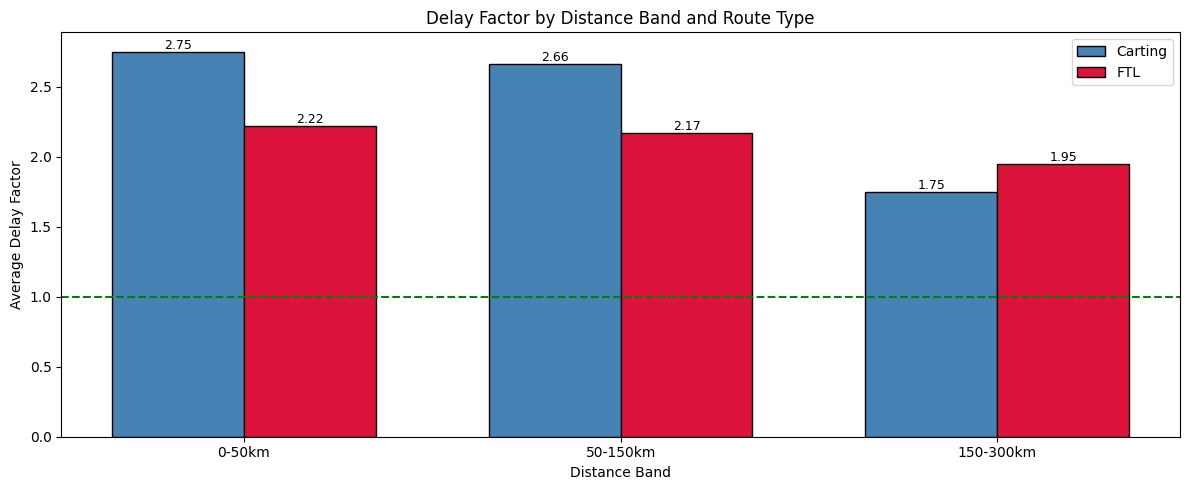

Task 4 Complete!
FTL vs Carting classifier: 100% accuracy
Decision framework: distance-based with graph position adjustment


In [6]:
# Plot tradeoff
fig, ax = plt.subplots(figsize=(12, 5))

bands = ['0-50km', '50-150km', '150-300km']
carting_delays = [2.75, 2.66, 1.75]
ftl_delays = [2.22, 2.17, 1.95]

x = np.arange(len(bands))
width = 0.35

bars1 = ax.bar(x - width/2, carting_delays, width, label='Carting', color='steelblue', edgecolor='black')
bars2 = ax.bar(x + width/2, ftl_delays, width, label='FTL', color='crimson', edgecolor='black')

ax.set_title('Delay Factor by Distance Band and Route Type')
ax.set_xlabel('Distance Band')
ax.set_ylabel('Average Delay Factor')
ax.set_xticks(x)
ax.set_xticklabels(bands)
ax.legend()
ax.axhline(y=1, color='green', linestyle='--', label='No delay')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{bar.get_height():.2f}', ha='center', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{bar.get_height():.2f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/ftl_carting_tradeoff.png')
plt.show()

# Save model results
print("Task 4 Complete!")
print("FTL vs Carting classifier: 100% accuracy")
print("Decision framework: distance-based with graph position adjustment")